In [1]:
# Import
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd

import sys

from tqdm.auto import tqdm
import torch
import torch.nn as nn


In [2]:
print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 1.26.4
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu


In [3]:
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


# 数据准备

## 计算均值和方差

In [4]:
def cal_mean_std(ds):
    mean = 0.
    std = 0.

    for img, _ in ds:
        mean += img.mean(dim=(1, 2));
        std += img.std(dim=(1, 2));

    mean /= len(ds)
    std /= len(ds)
    return mean, std

In [5]:
from torchvision import datasets
from torchvision import transforms

# 定义数据集变换
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图片转为 Tensor, 并归一化
    # transforms.Normalize(mean, std)  # 标准化
])

# fashion_mnist图像分类数据集，衣服分类，60000张训练图片，10000张测试图片
train_ds = datasets.FashionMNIST(
    root='data',  # 数据集存放的位置
    train=True,  # 训练集
    transform=transform,  # 数据变换
    download=True  # 下载数据集
)

test_ds = datasets.FashionMNIST(
    root='data',
    train=False,
    transform=transform,
    download=True
)

# torchvision 数据集里没有提供训练集和验证集的划分
# 当然也可以用 torch.utils.data.Dataset 实现人为划分

# 熟悉数据

In [6]:
type(train_ds)

torchvision.datasets.mnist.FashionMNIST

In [7]:
len(train_ds)

60000

In [8]:
type(train_ds[0])

tuple

In [9]:
img, label = train_ds[0]

In [10]:
img.shape

torch.Size([1, 28, 28])

In [11]:
type(img)

torch.Tensor

In [12]:
img[0]

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510, 0.2863, 0.0000,
         0.0000, 0.0039, 0.0157, 0.0000, 0.0000, 0.0000

In [13]:
img

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

In [14]:
label

9

## 显示图片

In [15]:
def show_img_cont(img):
    print("图像大小:", img.size)
    print("图像模式:", img.mode)

    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)

In [16]:
show_img_cont(img)  #这里必须把上面的 transforms.ToTensor(), # 转换为tensor，进行归一化注释掉，否则是不行的

图像大小: <built-in method size of Tensor object at 0x000001A99F13E120>
图像模式: <built-in method mode of Tensor object at 0x000001A99F13E120>


In [17]:
#这个代码必须是注释了上面的 transforms.ToTensor()才能够运行的
def show_single_image(img_arr):
    plt.imshow(img_arr, cmap="binary")  # 显示图片
    plt.colorbar()  # 显示颜色条
    plt.show()

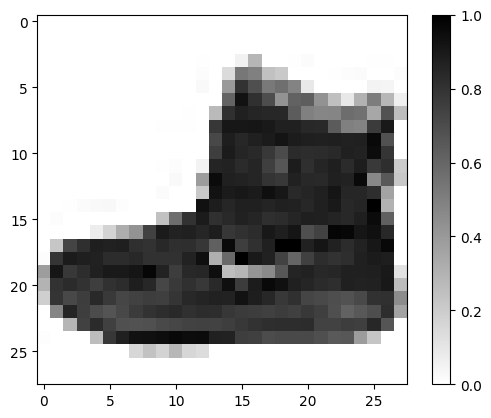

In [18]:
show_single_image(img[0])

In [19]:
def show_imgs(n_rows, n_cols, train_ds, class_names):
    assert n_rows * n_cols < len(train_ds)  #确保打印的图片小于总样本数
    plt.figure(figsize=(n_cols * 1.4, n_rows * 1.6))  #宽1.4高1.6，宽，高
    for row in range(n_rows):
        for col in range(n_cols):
            index = n_cols * row + col  # 计算索引，从0开始
            plt.subplot(n_rows, n_cols, index + 1)  #因为从1开始
            img_arr, label = train_ds[index]
            img_arr = np.transpose(img_arr, (1, 2, 0))  # 通道换到最后一维
            plt.imshow(img_arr, cmap="binary",
                       interpolation='nearest')  #interpolation='nearest'是临近插值
            plt.axis('off')  #去除坐标系
            plt.title(class_names[label])  # 显示类别名称
    plt.show()

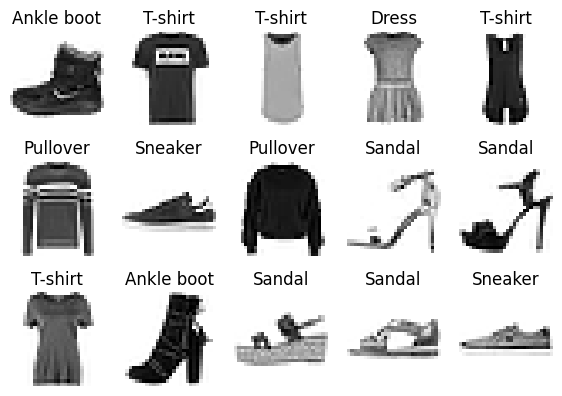

In [20]:
#已知的图片类别
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress',
               'Coat', 'Sandal', 'Shirt', 'Sneaker',
               'Bag', 'Ankle boot']  #0-9分别代表的类别
#只是打印了前15个样本
show_imgs(3, 5, train_ds, class_names)

# 从数据集到dataloader
在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

In [21]:
batch_size = 32
train_lorder = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_lorder = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False)
#batch_size分批，shuffle洗牌

# 定义模型

In [22]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()  # 继承父类的初始化方法，子类有父类的属性
        self.flatten = nn.Flatten()  # 将输入的多维张量展平为一维向量
        self.linear_relu_stack = nn.Sequential(  # 定义神经网络的层结构，包括线性层和激活函数ReL
            nn.Linear(28 * 28, 300),  # 第一个全连接层：输入维度为28*28(784)，输出维度为300
            nn.ReLU(),  # ReLU激活函数，引入非线性
            nn.Linear(300, 100),  # 第二个全连接层：输入维度为300，输出维度为100
            nn.ReLU(),
            nn.Linear(100, 10),  # 输出层：输入维度为100，输出维度为10(对应10个类
        )

    def forward(self, x):  # 定义前向传播方法
        # x.shape = [batch_size, 1, 28, 28]
        x = self.flatten(x)
        # 展平后 x.shape = [batch_size, 28 * 28]
        logits = self.linear_relu_stack(x)
        # 输出 logits.shape = [batch_size, 10]

        return logits  # 没有经过softmax

In [23]:
model = NeuralNetwork()

## 查看网络结构

In [24]:
model

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Linear(in_features=300, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [25]:
# 计算参数数量
784 * 300 + 300 + 300 * 100 + 100 + 100 * 10 + 10  #即模型中所有可训练参数的个数，乘以参数的元素个数，然后求和

266610

In [26]:
for name, param in model.named_parameters():  # 打印模型参数
    print(name, param.shape)

linear_relu_stack.0.weight torch.Size([300, 784])
linear_relu_stack.0.bias torch.Size([300])
linear_relu_stack.2.weight torch.Size([100, 300])
linear_relu_stack.2.bias torch.Size([100])
linear_relu_stack.4.weight torch.Size([10, 100])
linear_relu_stack.4.bias torch.Size([10])


In [27]:
# 查看模型参数
list(model.parameters())  # 这种方法拿到模型的所有可学习参数,requires_grad=True

[Parameter containing:
 tensor([[ 0.0162, -0.0278,  0.0328,  ..., -0.0046,  0.0227, -0.0161],
         [ 0.0276,  0.0158,  0.0084,  ...,  0.0058, -0.0114,  0.0038],
         [ 0.0089, -0.0161,  0.0128,  ...,  0.0056,  0.0107, -0.0266],
         ...,
         [-0.0152,  0.0119, -0.0237,  ..., -0.0294,  0.0114,  0.0073],
         [ 0.0305, -0.0268,  0.0350,  ...,  0.0030, -0.0083,  0.0007],
         [-0.0147, -0.0288, -0.0015,  ..., -0.0061, -0.0324,  0.0088]],
        requires_grad=True),
 Parameter containing:
 tensor([-1.1981e-02,  1.8030e-02, -2.5921e-02,  3.6271e-03,  2.3484e-03,
         -1.0291e-02,  1.4914e-02, -2.1061e-02, -2.3833e-02, -2.8104e-02,
         -3.3483e-02, -3.1418e-02,  2.4142e-02,  1.5705e-02, -1.8705e-02,
          2.5065e-02,  1.6074e-02, -3.1393e-02, -1.1920e-02,  1.9752e-02,
          1.1077e-02,  3.5166e-02, -1.1569e-02, -9.8288e-04,  1.8055e-02,
          1.9939e-02,  9.1400e-04, -1.5061e-02,  6.3889e-04,  3.2738e-03,
          2.7343e-02,  3.3217e-02, -3.05

In [28]:
model.state_dict()  # 这种方法用于保存模型参数，看能看见参数属于模型的哪一部分

OrderedDict([('linear_relu_stack.0.weight',
              tensor([[ 0.0162, -0.0278,  0.0328,  ..., -0.0046,  0.0227, -0.0161],
                      [ 0.0276,  0.0158,  0.0084,  ...,  0.0058, -0.0114,  0.0038],
                      [ 0.0089, -0.0161,  0.0128,  ...,  0.0056,  0.0107, -0.0266],
                      ...,
                      [-0.0152,  0.0119, -0.0237,  ..., -0.0294,  0.0114,  0.0073],
                      [ 0.0305, -0.0268,  0.0350,  ...,  0.0030, -0.0083,  0.0007],
                      [-0.0147, -0.0288, -0.0015,  ..., -0.0061, -0.0324,  0.0088]])),
             ('linear_relu_stack.0.bias',
              tensor([-1.1981e-02,  1.8030e-02, -2.5921e-02,  3.6271e-03,  2.3484e-03,
                      -1.0291e-02,  1.4914e-02, -2.1061e-02, -2.3833e-02, -2.8104e-02,
                      -3.3483e-02, -3.1418e-02,  2.4142e-02,  1.5705e-02, -1.8705e-02,
                       2.5065e-02,  1.6074e-02, -3.1393e-02, -1.1920e-02,  1.9752e-02,
                       1.1077e-0

# 训练模型
pytorch的训练需要自行实现，包括
1. 定义损失函数
2. 定义优化器
3. 定义训练步
4. 训练

In [29]:
# 1.定义损失函数，使用交叉熵损失函数
loss_fct = nn.CrossEntropyLoss()  #内部先做softmax，然后计算交叉熵
# 2.定义优化器,使用SGD优化器
optimizer = torch.optim.SGD(model.parameters(), lr=0.001,
                            momentum=0.9)  # model.parameters()是所有可学习参数，lr是学习率，momentum是动量，用于加速训练
# 优化器的作用是根据损失函数的梯度来更新参数，使得模型参数的梯度方向和损失函数的梯度方向一致，从而达到最小化损失函数的目的。

In [30]:
# 评估模型
@torch.no_grad()  # 装饰器，禁止反向传播，节省内存
def evaluator(model, dataloader, loss_fct):
    loss_list = []  # 记录损失
    pred_list = []  # 记录预测
    label_list = []  # 记录标签
    for data, label in dataloader:  #10000/32=312,
        # 转到GPU
        data = data.to(device)
        label = label.to(device)

        # 前向传播
        logits = model(data)
        loss = loss_fct(logits, label)  # 验证集损失
        loss_list.append(loss.item())  # 记录损失
        pred = logits.argmax(axis=-1)  # 预测
        pred_list.extend(pred.cpu().numpy().tolist())  #将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())  #将PyTorch张量转换为NumPy数组。只有当张量在CPU上时，这个转换才是合法的

        acc = (pred == label).sum().item() / len(label)  # 准确率

        return np.mean(loss_list), acc

In [31]:
# 训练
def training(model, train_lorder, val_lorder, loss_fct, optimizer, epochs, eval_step=500):
    record_dict = {
        "train": [],  # 记录训练损失和准确率
        "val": []  # 记录验证损失和准确率
    }

    global_step = 0
    model.train()  # 训练模式
    with tqdm(total=epochs * len(train_lorder)) as pbar:  # 进度条,1875*20,60000/32=1875
        for epoch in range(epochs):
            # training
            for data, label in train_lorder:  #执行次数是60000/32=1875
                # 转到GPU
                data = data.to(device)
                label = label.to(device)
                # 梯度清空
                optimizer.zero_grad()
                # 前向传播
                logits = model(data)
                # 计算损失
                loss = loss_fct(logits, label)  # 验证集损失
                # 反向传播,梯度回传，loss.backward()会计算梯度，loss对模型参数求导
                loss.backward()
                # 调整优化器，包括学习率的变动等,优化器的学习率会随着训练的进行而减小，更新w,b
                # 梯度是计算并存储在模型参数的 .grad 属性中，优化器使用这些存储的梯度来更新模型参数
                optimizer.step()
                # 训练集预测
                pred = logits.argmax(axis=-1)  # 预测
                # 计算准确率
                acc = (pred == label).sum().item() / len(label)
                # 记录损失
                loss = loss.cpu().item()
                # 记录训练集信息，每一步的损失，准确率，步数
                record_dict["train"].append({"loss": loss, "acc": acc, "step": global_step})
                # evaluating
                if global_step % eval_step == 0:
                    model.eval()  # 评估模式
                    val_loss, val_acc = evaluator(model, val_lorder, loss_fct)
                    record_dict["val"].append({"loss": val_loss, "acc": val_acc, "step": global_step})
                    model.train()  # 训练模式

                global_step += 1  # 全局步数加1
                pbar.update(1)  # 更新进度条
                pbar.set_postfix({"epoch": epoch})  # 设置进度条显示信息

        return record_dict

In [32]:
epoch = 20  #改为40
# model = NeuralNetwork()
model = model.to(device)
record = training(model, train_lorder, val_lorder, loss_fct, optimizer, epoch, eval_step=1000)

  0%|          | 0/37500 [00:00<?, ?it/s]

In [33]:
record["train"][-5:]

[{'loss': 0.16528400778770447, 'acc': 0.96875, 'step': 37495},
 {'loss': 0.2948126792907715, 'acc': 0.875, 'step': 37496},
 {'loss': 0.2820436954498291, 'acc': 0.9375, 'step': 37497},
 {'loss': 0.13201482594013214, 'acc': 0.96875, 'step': 37498},
 {'loss': 0.15439851582050323, 'acc': 0.9375, 'step': 37499}]

In [34]:
record["val"][-5:]

[{'loss': 0.3744247853755951, 'acc': 0.84375, 'step': 33000},
 {'loss': 0.3343796133995056, 'acc': 0.90625, 'step': 34000},
 {'loss': 0.325865238904953, 'acc': 0.84375, 'step': 35000},
 {'loss': 0.31191614270210266, 'acc': 0.875, 'step': 36000},
 {'loss': 0.3175591826438904, 'acc': 0.875, 'step': 37000}]

# loss-step和acc-step曲线

In [35]:
def plot_learning_curves(record_dict, sample_step=1000):
    # build DataFrame
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]  # 最后一步的步数

    # plot
    fig_num = len(train_df.columns)  # 画几张图,分别是损失和准确率
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        # print(train_df[item].values)
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()  # 显示网格
        axs[idx].legend()  # 显示图例
        axs[idx].set_xticks(range(0, train_df.index[-1], 5000))  # 设置x轴刻度
        axs[idx].set_xticklabels(map(lambda x: f"{int(x / 1000)}k", range(0, last_step, 5000)))  # 设置x轴标签
        axs[idx].set_xlabel("step")

    plt.show()

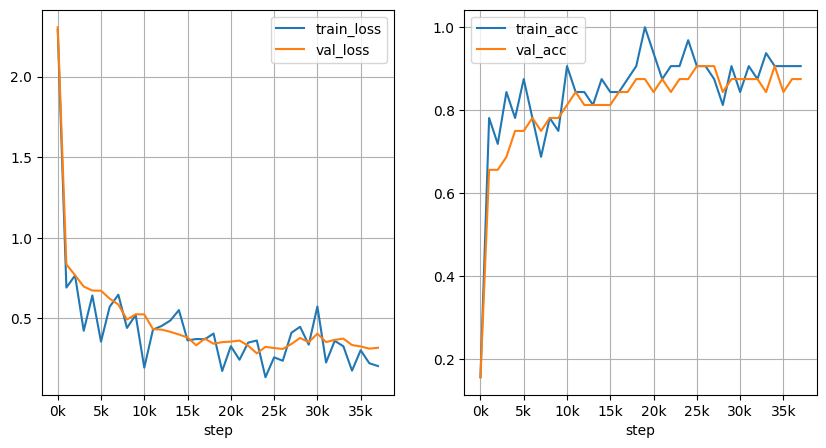

In [36]:
plot_learning_curves(record)  #横坐标是 steps

# 评估

In [37]:
model.eval()  # 进入评估模式
loss, acc = evaluator(model, val_lorder, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")

loss:     0.3249
accuracy: 0.8750
